In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
text = " ".join(df['review'].head(100))

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
tokens = word_tokenize(text.lower())
print("total words ",len(tokens))

total words  28043


In [ ]:
bigrams = list(ngrams(tokens,2))
trigrams = list(ngrams(tokens,3))


In [ ]:
bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

In [ ]:
print("Top Bigrams ")
print(bigram_freq.most_common(10))
print("Top Trigrams ")
print(trigram_freq.most_common(10))

Top Bigrams 
[(('<', 'br'), 458), (('br', '/'), 458), (('/', '>'), 458), (('>', '<'), 229), (('of', 'the'), 152), (('in', 'the'), 117), ((',', 'and'), 101), (('.', 'the'), 91), ((',', 'but'), 82), (('it', "'s"), 81)]
Top Trigrams 
[(('<', 'br', '/'), 458), (('br', '/', '>'), 458), (('/', '>', '<'), 229), (('>', '<', 'br'), 229), (('/', '>', 'the'), 43), (('.', '<', 'br'), 30), (('/', '>', 'i'), 23), (('one', 'of', 'the'), 21), (('.', 'it', "'s"), 21), (('/', '>', 'this'), 15)]


In [ ]:
top_bigrams = bigram_freq.most_common(10)
top_trigrams = trigram_freq.most_common(10)

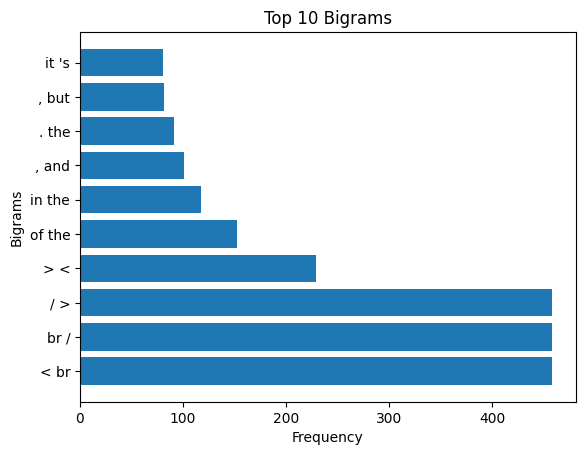

In [ ]:
words = [" ".join(bg[0]) for bg in top_bigrams]
counts = [bg[1] for bg in top_bigrams]

plt.barh(words,counts)
plt.title("Top 10 Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

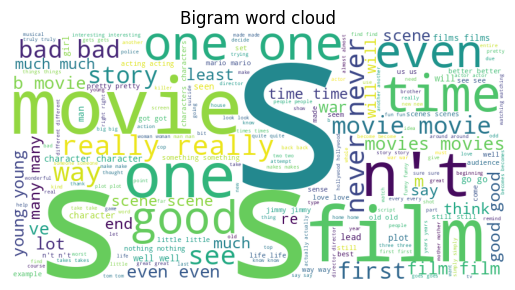

In [ ]:
bigram_text = [" ".join(bg) for bg in bigram_freq]
wordcloud = WordCloud(width = 800,height = 400, background_color='white').generate(" ".join(bigram_text))

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Bigram word cloud')
plt.show()

In [ ]:
def predict_next_word(word):
  candidates = []
  for(w1,w2),freq in bigram_freq.items():
    if w1 == word:
      candidates.append((w2,freq))

  candidates = sorted(candidates,key=lambda x:x[1],reverse=True)
  return candidates[:5]

In [ ]:
predict_next_word("the")

[('movie', 60), ('film', 46), ('story', 26), ('first', 16), ('end', 16)]

In [ ]:
def predict_next_word_trigram(w1,w2):
  results = []
  for (a,b,c),freq in trigram_freq.items():
    if a == w1 and b == w2:
      results.append((c,freq))

  results = sorted(results,key=lambda x:x[1],reverse=True)
  return results[:5]

In [ ]:
predict_next_word_trigram("I","love")

[]

In [ ]:
trigrams = list(ngrams(tokens,3))
trigram_freq = Counter(trigrams)

print("Sample Trigrams")
print(trigram_freq.most_common(10))

Sample Trigrams
[(('<', 'br', '/'), 458), (('br', '/', '>'), 458), (('/', '>', '<'), 229), (('>', '<', 'br'), 229), (('/', '>', 'the'), 43), (('.', '<', 'br'), 30), (('/', '>', 'i'), 23), (('one', 'of', 'the'), 21), (('.', 'it', "'s"), 21), (('/', '>', 'this'), 15)]


In [ ]:
def autocomplete_sentence(sentence):
  words = word_tokenize(sentence.lower())
  if len(words) < 2:
    return "Enter atleast 2 words"
  w1,w2 = words[-2],words[-1]
  predictions = []
  for(a,b,c), freq in trigram_freq.items():
    if a == w1 and b == w2:
      predictions.append((c,freq))

  predictions = sorted(predictions,key=lambda x:x[1],reverse=True)

  return [word for word,freq in predictions[:5]]

In [ ]:
sentence = "this movie"
autocomplete_sentence(sentence)

['is', ',', '.', 'was', 'and']

In [ ]:
def generate_sentence(sentence):
  next_words = autocomplete_sentence(sentence)
  results = []
  for word in next_words:
    results.append(sentence + " " + word)
  return results

In [ ]:
generate_sentence("this movie")

['this movie is',
 'this movie ,',
 'this movie .',
 'this movie was',
 'this movie and']

In [ ]:
user_input = input("Enter a sentence ")
predictions = generate_sentence(user_input)
print("\nAuto Completed sentence")
for s in predictions:
  print(s)

Enter a sentence This movie

Auto Completed sentence
This movie is
This movie ,
This movie .
This movie was
This movie and


## Task

Apply n-gram on news dataset from Kaggle

Generate 4-gram sequences for the dataset

Create a trigram word cloud visualization

Compare bigram vs trigram prediction accuracy

Build a sentence Auto-Completion System

In [ ]:
news_df = pd.read_csv('Articles.csv', encoding='latin1')
news_df.head()

,Article,Date,Heading,NewsType
0,KARACHI: The Sindh government has decided to b...,1/1/2015,sindh govt decides to cut public transport far...,business
1,HONG KONG: Asian markets started 2015 on an up...,1/2/2015,asia stocks up in new year trad,business
2,HONG KONG: Hong Kong shares opened 0.66 perce...,1/5/2015,hong kong stocks open 0.66 percent lower,business
3,HONG KONG: Asian markets tumbled Tuesday follo...,1/6/2015,asian stocks sink euro near nine year,business
4,NEW YORK: US oil prices Monday slipped below $...,1/6/2015,us oil prices slip below 50 a barr,business


In [ ]:
from nltk.corpus import stopwords

news_text_corpus = " ".join(news_df['Article'].astype(str))
print(f"Total characters in news text: {len(news_text_corpus)}")

Total characters in news text: 4875264


In [ ]:
news_tokens = word_tokenize(news_text_corpus.lower())

news_tokens = [word for word in news_tokens if word.isalpha()]
print("Total words after initial cleaning:", len(news_tokens))

Total words after initial cleaning: 728106


## Generate 4-gram sequences for the dataset

In [ ]:
news_4grams = list(ngrams(news_tokens, 4))
news_4gram_freq = Counter(news_4grams)
print("Top 10 Four-grams:")
print(news_4gram_freq.most_common(10))

Top 10 Four-grams:
[(('for', 'the', 'first', 'time'), 159), (('won', 'the', 'toss', 'and'), 137), (('percent', 'or', 'points', 'to'), 123), (('benchmark', 'west', 'texas', 'intermediate'), 122), (('in', 'the', 'united', 'states'), 95), (('million', 'barrels', 'per', 'day'), 94), (('said', 'in', 'a', 'statement'), 86), (('at', 'the', 'end', 'of'), 85), (('west', 'texas', 'intermediate', 'wti'), 84), (('of', 'the', 'petroleum', 'exporting'), 80)]


## Create a trigram word cloud visualization

In [ ]:
news_trigrams = list(ngrams(news_tokens, 3))
news_trigram_freq = Counter(news_trigrams)
print("Top 10 Trigrams for News Dataset:")
print(news_trigram_freq.most_common(10))

Top 10 Trigrams for News Dataset:
[(('said', 'in', 'a'), 299), (('in', 'the', 'first'), 299), (('the', 'united', 'states'), 275), (('one', 'of', 'the'), 233), (('for', 'the', 'first'), 222), (('in', 'the', 'second'), 204), (('the', 'first', 'time'), 195), (('west', 'texas', 'intermediate'), 191), (('in', 'the', 'world'), 190), (('the', 'end', 'of'), 186)]


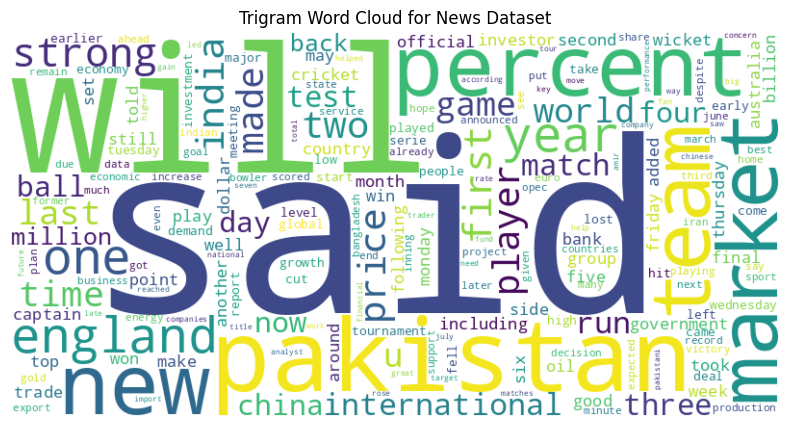

In [ ]:
trigram_news_text = [" ".join(tg) for tg in news_trigram_freq.keys()]
wordcloud_trigram = WordCloud(width = 800, height = 400, background_color='white').generate(" ".join(trigram_news_text))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_trigram, interpolation='bilinear')
plt.axis('off')
plt.title('Trigram Word Cloud for News Dataset')
plt.show()

## Compare bigram vs trigram prediction accuracy

In [ ]:
news_bigrams = list(ngrams(news_tokens, 2))
news_bigram_freq = Counter(news_bigrams)
print("Top 10 Bigrams for News Dataset:")
print(news_bigram_freq.most_common(10))

Top 10 Bigrams for News Dataset:
[(('in', 'the'), 5766), (('of', 'the'), 4563), (('for', 'the'), 2062), (('to', 'the'), 1913), (('on', 'the'), 1603), (('at', 'the'), 1573), (('in', 'a'), 1390), (('the', 'first'), 1190), (('and', 'the'), 1021), (('with', 'the'), 998)]


In [ ]:
def predict_next_word_news_bigram(word):
  candidates = []
  for (w1, w2), freq in news_bigram_freq.items():
    if w1 == word:
      candidates.append((w2, freq))

  candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
  return candidates[:5]

In [ ]:
def predict_next_word_news_trigram(w1, w2):
  results = []
  for (a, b, c), freq in news_trigram_freq.items():
    if a == w1 and b == w2:
      results.append((c, freq))

  results = sorted(results, key=lambda x: x[1], reverse=True)
  return results[:5]

In [ ]:
print("Bigram prediction for 'the':", predict_next_word_news_bigram('the'))

Bigram prediction for 'the': [('first', 1190), ('world', 950), ('second', 571), ('last', 458), ('country', 422)]


In [ ]:
print("Trigram prediction for 'in', 'the':", predict_next_word_news_trigram('in', 'the'))

Trigram prediction for 'in', 'the': [('first', 299), ('second', 204), ('world', 190), ('last', 146), ('united', 124)]


## Build a sentence Auto-Completion System

In [ ]:
def autocomplete_sentence_news(sentence):
    words = word_tokenize(sentence.lower())
    if len(words) < 2:
        if len(words) == 1:
            last_word = words[-1]
            predictions = predict_next_word_news_bigram(last_word)
            return [word for word, freq in predictions]
        return []

    w1, w2 = words[-2], words[-1]
    predictions = predict_next_word_news_trigram(w1, w2)
    return [word for word, freq in predictions]

In [ ]:
def generate_sentence_news(sentence):
    next_words = autocomplete_sentence_news(sentence)
    if not next_words:
        return [sentence]
    results = []
    for word in next_words:
        results.append(sentence + " " + word)
    return results

In [ ]:
user_input_news = input("Enter a sentence for news autocomplete: ")
predictions_news = generate_sentence_news(user_input_news)
print("\nAuto Completed sentence (News):")
for s in predictions_news:
    print(s)

Enter a sentence for news autocomplete: This movie

Auto Completed sentence (News):
This movie


In [ ]:
print("Bigram prediction for 'the':", predict_next_word_news_bigram('the'))

Bigram prediction for 'the': [('first', 1190), ('world', 950), ('second', 571), ('last', 458), ('country', 422)]


In [ ]:
print("Trigram prediction for 'in', 'the':", predict_next_word_news_trigram('in', 'the'))

Trigram prediction for 'in', 'the': [('first', 299), ('second', 204), ('world', 190), ('last', 146), ('united', 124)]


In [ ]:
user_input_news = input("Enter a sentence for news autocomplete: ")
predictions_news = generate_sentence_news(user_input_news)
print("\nAuto Completed sentence (News):")
for s in predictions_news:
    print(s)

Enter a sentence for news autocomplete: Karachi is

Auto Completed sentence (News):
Karachi is not
Karachi is one


In [ ]:
print("Bigram prediction for 'the':", predict_next_word_news_bigram('the'))

Bigram prediction for 'the': [('first', 1190), ('world', 950), ('second', 571), ('last', 458), ('country', 422)]


In [ ]:
print("Trigram prediction for 'in', 'the':", predict_next_word_news_trigram('in', 'the'))

Trigram prediction for 'in', 'the': [('first', 299), ('second', 204), ('world', 190), ('last', 146), ('united', 124)]


In [ ]:
def autocomplete_sentence_news(sentence):
    words = word_tokenize(sentence.lower())
    if len(words) < 2:
        if len(words) == 1:
            last_word = words[-1]
            predictions = predict_next_word_news_bigram(last_word)
            return [word for word, freq in predictions]
        return []

    w1, w2 = words[-2], words[-1]
    predictions = predict_next_word_news_trigram(w1, w2)
    return [word for word, freq in predictions]

In [ ]:
def generate_sentence_news(sentence):
    next_words = autocomplete_sentence_news(sentence)
    if not next_words:
        return [sentence]
    results = []
    for word in next_words:
        results.append(sentence + " " + word)
    return results

In [ ]:
user_input_news = input("Enter a sentence for news autocomplete: ")
predictions_news = generate_sentence_news(user_input_news)
print("\nAuto Completed sentence (News):")
for s in predictions_news:
    print(s)

Enter a sentence for news autocomplete: I am

Auto Completed sentence (News):
I am not
I am very
I am sure
I am happy
I am underestimating


## Conclusion

This notebook effectively demonstrated N-gram model applications for Natural Language Processing. We performed N-gram analysis (bigrams, trigrams, and 4-grams) on both movie review and news datasets. Key visualizations included bigram and trigram word clouds. We also developed and compared basic word prediction and sentence autocomplete systems using bigrams and trigrams, highlighting their utility in text understanding and language modeling.